<img src="https://udemedellin.edu.co/wp-content/uploads/2022/10/logo_udemedellin2.png" width="30%">

**ESPECIALIZACIÓN EN CIENCIA DE DATOS E INTELIGENCIA ARTIFICIAL**

*INTRODUCCION A LA CIENCIA DE DATOS*<br>

DOCENTE:<br>
Mateo Cano Solis<br>

NOMBRES:
1. Santiago Castañeda Garcia
2. Andres Eduardo Medina
3. David Alejandro Montilla Orjuela



Abril 2026


---

# **Análisis Predictivo y Caracterización de la Contratación Estatal en Colombia: Un Enfoque Basado en Datos de SECOP I y II**

## **1. introducción:**
La contratación pública en Colombia representa uno de los pilares más importantes para el desarrollo socioeconómico del país. Con la transición y coexistencia de las plataformas SECOP I y SECOP II, se ha generado un volumen de información sin precedentes sobre cómo el Estado invierte sus recursos. Sin embargo, la complejidad y diversidad de estos datos exigen el uso de herramientas avanzadas de Analítica de Datos para transformar registros administrativos en conocimiento estratégico.

Este proyecto se enfoca en el estudio de los procesos de compra pública que han culminado en contratos efectivos. A través de técnicas de Aprendizaje Automático (Machine Learning), se busca descubrir patrones ocultos en las modalidades de selección, los tiempos de ejecución y la distribución de los presupuestos, permitiendo una visión técnica que aporte a la transparencia y a la eficiencia en la gestión pública

<br><br>

## **2. Objetivos:**

Objetivo General
Desarrollar un modelo de análisis basado en técnicas de aprendizaje automático para caracterizar y predecir métricas clave en los procesos de contratación estatal integrados en las plataformas SECOP I y II.

Objetivos Específicos
Realizar un Análisis Exploratorio de Datos (EDA) para identificar las tendencias de contratación por sectores, regiones y modalidades de selección.

Procesar y estandarizar la información integrada de SECOP I y II, gestionando la limpieza de datos faltantes y la codificación de variables categóricas.

Evaluar diferentes arquitecturas de modelos predictivos mediante el uso de herramientas de AutoML (como AutoGluon), con el fin de determinar el algoritmo que ofrezca mayor precisión en la clasificación o estimación de resultados contractuales.

Interpretar los resultados obtenidos para identificar qué variables (como cuantía, ubicación o tipo de entidad) tienen mayor peso en la configuración de un contrato exitoso.

<br>
VARIABLES OBSERVADAS
<br><br>

|Num|Nombre de la columna|Descripción|Nombre del campo API|Tipo de dato|
|-|-|-|-|-|
|1|Nivel Entidad|Nivel de la entidad publica que desarrolla el proceso de compra, de acuerdo a su cobertura|Nivel entidad|Texto|
|2|Código Entidad SECOP|Código de la entidad en la plataforma SEECOP|Código_entidad_en_secop|Texto |
|3|Nombre de la Entidad|Nombre de la Entidad que desarrolla el proceso de compra pública|nombre_de_la_entidad|Texto |
|4|NIT de la Entidad|	Identificador de la Entidad que desarrolla el proceso de compra pública|nit_de_la_entidad|	Texto|
|5|Departamento Entidad|	Departamento de origen de la Entidad en la plataforma SECOP|	departamento_entidad|	Texto|
|6|Municipio Entidad|	Municipio de origen de la Entidad en la plataforma SECOP|	municipio_entidad|	Texto|
|7|Estado del Proces|	Estado del proceso, de acuerdo con el flujo que se establece y a la modalidad de adquisición bajo la cual se desarrolla|	estado_del_proceso|	Texto|
|8|Modalidad de Contratación|	Modo de adquisición, de acuerdo con las características del proceso y del producto o servicio involucrados|	modalidad_de_contrataci_n|	Texto|
|9|Objeto del contrato|	Descripción detallada del producto o servicio a adquirir, definida al momento de redactar el contrato|	objeto_a_contratar|	Texto|
|10|Objeto del proceso|	Objeto de contratación registrado en la fase de publicación del proceso|	objeto_del_proceso|	Texto|
|11|Tipo de Contrato|	Tipo de contrato que se firma al finalizar el proceso de compra pública|	tipo_de_contrato|	Texto|
|12|Fecha de Firma del Contrato|	Fecha en que se firmó el contrato, sea de forma física o digital|	fecha_de_firma_del_contrato|	Marca de tiempo variable|
|13|Fecha inicio ejecución|	Fecha de Inicio de Ejecución del Contrato|	fecha_inicio_ejecuci_n|	Marca de tiempo variable|
|14|Fecha fin ejecución|	Fecha definida en el contrato como la fecha de finalización de la ejecución|	fecha_fin_ejecuci_n|	Marca de tiempo variable|
|15|ID Contrato|	Identificador en la plataforma del contrato firmado|	numero_del_contrato|	Texto|
|16|ID Proceso|	identificador en la plataforma del proceso desarrollado|	numero_de_proceso|	Texto|
|17|Valor Contrato|	Valor del contrato firmado|	valor_contrato	|numerica|
|18|Núm Raz Social Contratista|Nombre del contratista o de la empresa que proveerá los productos o servicios relacionados en el proceso de compra|num_raz_social_contratista|Texto|
|19|	URL Contrato|	URL del proceso en su correspondiente plataforma.|	url_contrato|	Texto|
|20	|Origen	|Plataforma Origen a donde pertenecen los datos|	origen	|Texto|
|21	|Tipo Documento Proveedor	|Corresponde al tipo de documento del proveedor	|tipo_documento_proveedor|	Texto|
|22|	Documento Proveedor	|Corresponde al número de documento del proveedor|	documento_proveedor	|Texto|






## **Carga de librerias y datos:**

In [1]:
#Importacion de librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import seaborn as sns
import unicodedata
import re
from catboost import CatBoostRegressor
import warnings
import seaborn as sns



df = pd.read_parquet('data/datos_secop.parquet')

#visualizar todo el df en pantalla
pd.set_option('display.max_columns', None)

# generar variable para conteo final de Nas
filas_iniciales = len(df)

#numero de columnas y filas
print(f"El dataset tiene: {df.shape[0]} filas y {df.shape[1]} columnas")



El dataset tiene: 300000 filas y 22 columnas


## **Variables**

## **Visualizar el df**

In [2]:
# Mostrar  5 filas aleatorias
df.sample(5,random_state=25)

,nivel_entidad,codigo_entidad_en_secop,nombre_de_la_entidad,nit_de_la_entidad,departamento_entidad,municipio_entidad,estado_del_proceso,modalidad_de_contrataci_n,objeto_a_contratar,objeto_del_proceso,tipo_de_contrato,fecha_de_firma_del_contrato,fecha_inicio_ejecuci_n,fecha_fin_ejecuci_n,numero_del_contrato,numero_de_proceso,valor_contrato,nom_raz_social_contratista,url_contrato,origen,tipo_documento_proveedor,documento_proveedor
98576,Territorial,706294725,MUNICIPIO DE PUERTO GAITAN,800079035,Meta,Puerto Gaitán,En ejecución,Contratación directa,PRESTACION DE SERVICIOS DE APOYO A LA GESTION ...,PRESTACION DE SERVICIOS DE APOYO A LA GESTION ...,Prestación de servicios,2025-10-24T00:00:00.000,2025-10-24T00:00:00.000,2025-12-24T00:00:00.000,CO1.PCCNTR.8496546,1457-2025,5693333,DANIELA STEFFANY ROJAS ORTIZ,https://community.secop.gov.co/Public/Tenderin...,SECOPII,Cédula de Ciudadanía,1124818345
267521,Territorial,702730482,SUBRED INTEGRADA DE SERVICIOS DE SALUD SUR E.S...,900958564,Distrito Capital de Bogotá,Bogotá,Modificado,Contratación régimen especial,PRESTAR SERVICIOS COMO PROFESIONAL UNIVERSITAR...,PRESTAR SERVICIOS COMO PROFESIONAL UNIVERSITAR...,Prestación de servicios,2025-10-02T00:00:00.000,2025-10-02T00:00:00.000,2026-01-09T00:00:00.000,CO1.PCCNTR.8401984,7218-2025,12585600,Milena Stefany Lopez Ramirez,https://community.secop.gov.co/Public/Tenderin...,SECOPII,Cédula de Ciudadanía,1018450196
286023,Territorial,701365033,MUNICIPIO DE ARMENIA QUINDIO,890000464,Quindío,Armenia,Aprobado,Contratación directa,PRESTACIÓN DE SERVICIOS DE APOYO A LA GESTIÓN ...,PRESTACIÓN DE SERVICIOS DE APOYO A LA GESTIÓN ...,Prestación de servicios,2025-11-27T00:00:00.000,None,2026-01-15T00:00:00.000,CO1.PCCNTR.8635700,SETTA-CD-2025-4677,3750000,Oscar Posada Yepes,https://community.secop.gov.co/Public/Tenderin...,SECOPII,Cédula de Ciudadanía,7529900
11020,Territorial,702727421,empresa social del estado región de salud soacha.,8000068503,Cundinamarca,Soacha,Borrador,Contratación régimen especial,NO DEFINIDO,Sin Descripcion,Prestación de servicios,None,None,None,CO1.PCCNTR.272027,CO1.PCCNTR.272027,0,NO DEFINIDO,https://community.secop.gov.co/Public/Tenderin...,SECOPII,Sin Descripcion,No Definido
219736,Territorial,702271321,(Secretaría Distrital de Integración Social),8999990619,Distrito Capital de Bogotá,No Definido,Aprobado,Contratación directa,PRESTAR SERVICIOS PROFESIONALES PARA REALIZAR ...,PRESTAR SERVICIOS PROFESIONALES PARA REALIZAR ...,Prestación de servicios,2025-11-18T00:00:00.000,None,2026-03-12T00:00:00.000,CO1.PCCNTR.8568972,11671-2025,15137640,DASSY MILENA GUTIERREZ,https://community.secop.gov.co/Public/Tenderin...,SECOPII,Cédula de Ciudadanía,52288055


## **EDA**

In [3]:
# Obtener un resumen de la estructura del conjunto de datos:

print("\n-------TABLA CON TIPO DE VARIABLE VALORES UNICOS Y VALORES FALTANTES-------\n")
def generar_diccionario(Data):
    dicc = []
    for col in Data.columns:
        dicc.append({
            "Variable": col,
            "Tipo pandas": Data[col].dtype,
            "Cantidad de valores únicos": Data[col].nunique(),
            "Valores faltantes": Data[col].isna().sum()
        })
    return pd.DataFrame(dicc)

generar_diccionario(df)


-------TABLA CON TIPO DE VARIABLE VALORES UNICOS Y VALORES FALTANTES-------



,Variable,Tipo pandas,Cantidad de valores únicos,Valores faltantes
0,nivel_entidad,object,7,0
1,codigo_entidad_en_secop,object,5103,0
2,nombre_de_la_entidad,object,5239,0
3,nit_de_la_entidad,object,4200,0
4,departamento_entidad,object,38,0
5,municipio_entidad,object,1079,0
6,estado_del_proceso,object,19,0
7,modalidad_de_contrataci_n,object,31,0
8,objeto_a_contratar,object,165211,0
9,objeto_del_proceso,object,172952,1


In [4]:
'''# 1. Configuración de variables y grid
vars_cualitativas = [
    'nombre_de_la_entidad', 'departamento_entidad', 'municipio_entidad', 
    'estado_del_proceso', 'tipo_de_contrato', 'nom_raz_social_contratista'
]

cols_grid = 2
rows_grid = math.ceil(len(vars_cualitativas) / cols_grid)

# Paleta de colores
colores_paleta = plt.cm.tab10.colors 

fig, axes = plt.subplots(rows_grid, cols_grid, figsize=(16, rows_grid * 5))
axes = axes.flatten()

for i, col in enumerate(vars_cualitativas):
    if col in df.columns:
        # Top 5 ordenado
        datos = df[col].value_counts().head(5).sort_values(ascending=True)

        ax = axes[i]
        
        # --- CAMBIO: Eliminamos 'label' para que no haya leyenda ---
        datos.plot(
            kind='barh', 
            ax=ax, 
            color=colores_paleta[:len(datos)], 
            edgecolor='black'
        )

        ax.set_title(f'Top 5: {col}', fontsize=13, fontweight='bold')
        ax.set_xlabel('Cantidad de contratos')
        ax.set_ylabel('')

        # --- CAMBIO: Eliminamos ax.legend() ---
        # La leyenda ya no se mostrará.

        # Estética
        ax.grid(False)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # Etiquetas de datos al final de la barra (aquí ya está el número)
        max_valor = datos.max()
        for p in ax.patches:
            ancho = p.get_width()
            ax.annotate(
                f' {int(ancho):,}', 
                (ancho, p.get_y() + p.get_height()/2.),
                va='center', 
                ha='left', 
                fontsize=11, 
                fontweight='bold'
            )
        
        ax.set_xlim(0, max_valor * 1.25)

    else:
        axes[i].axis('off')

# Ajustes finales
plt.tight_layout(pad=5.0)
fig.suptitle(
    'Top 5 de Variables Cualitativas - Análisis Visual',
    fontsize=22,
    fontweight='bold',
    y=1.02
)

plt.show()'''

"# 1. Configuración de variables y grid\nvars_cualitativas = [\n    'nombre_de_la_entidad', 'departamento_entidad', 'municipio_entidad', \n    'estado_del_proceso', 'tipo_de_contrato', 'nom_raz_social_contratista'\n]\n\ncols_grid = 2\nrows_grid = math.ceil(len(vars_cualitativas) / cols_grid)\n\n# Paleta de colores\ncolores_paleta = plt.cm.tab10.colors \n\nfig, axes = plt.subplots(rows_grid, cols_grid, figsize=(16, rows_grid * 5))\naxes = axes.flatten()\n\nfor i, col in enumerate(vars_cualitativas):\n    if col in df.columns:\n        # Top 5 ordenado\n        datos = df[col].value_counts().head(5).sort_values(ascending=True)\n\n        ax = axes[i]\n\n        # --- CAMBIO: Eliminamos 'label' para que no haya leyenda ---\n        datos.plot(\n            kind='barh', \n            ax=ax, \n            color=colores_paleta[:len(datos)], \n            edgecolor='black'\n        )\n\n        ax.set_title(f'Top 5: {col}', fontsize=13, fontweight='bold')\n        ax.set_xlabel('Cantidad de c

## **VALOR DEL CONTRATO**

Nuestra variable target es el valor del contrato el cual intentaremos predecir pero este tiene una escala que va desde miles de  pesos a billones es por eso que para el estudio, solo trabajaremos con los contratos de 1 millon a 200 millones que es donde mas se concentra la contratacion en Colombia.

## **Renombrar columnas**

In [5]:
# Quitar guion para los nombres de las columnas
df.rename(columns={'modalidad_de_contrataci_n': 'modalidad_de_contratacion', 'fecha_inicio_ejecuci_n': 'fecha_inicio_ejecucion',
    'fecha_fin_ejecuci_n': 'fecha_fin_ejecucion'},
    inplace=True)

## **Data cleaning**

OBSERVACION: 
 Existe en la columna (estado_del_proceso) contratos que estan en  borrador. lo que significa  que aun no están publicados oficialmente o no ha sido adjudicado o está en proceso de elaboración o revisión, por lo que carece de mucha de informacion en otras columnas, estas filas se eliminan para tener solo los contratos que ya pasaron la etapa de creación inicial

In [6]:
#Borrar contratos en estado borrador
df["estado_del_proceso"] = df["estado_del_proceso"].astype(str)
df["estado_del_proceso"] = df["estado_del_proceso"].str.lower()
df = df[df['estado_del_proceso'] != 'borrador']

numero_filas= df.shape[0]
#comprobamos cuantas filas quedan
print(f"el numero de filas resultantes es {df.shape[0]}")

el numero de filas resultantes es 272015


OBSERVACION: El dataset nos quedo con (f" **{numero_filas}**") filas lo cual nos dice que exisitian  27958 contratos que a la fecha no se han aprobado y fueron eliminados para nuestro estudio, ademas tenemos  75269  filas que no tienen fecha de inicio de ejecucion (fecha_inicio_ejecucion), esto puede deberse que el contrato aun no se ha iniciado por lo que no debe tener fecha de terminacion (fecha_fin_ejecucion). Buscamos las filas que no tienen fechas en ninguna de las dos columnas (fantasmas).

Pasar variables de fecha a formato datetime


In [7]:
#numero de filas sin fecha de inicio de ejcucion
filas_sin_fecha_ejecucion=df['fecha_inicio_ejecucion'].isna().sum()
print(f"el numero de filas sin fecha de inicio de ejcucion es: {filas_sin_fecha_ejecucion}")

el numero de filas sin fecha de inicio de ejcucion es: 75269


In [8]:
#aplicar fomato datetime

cols = ['fecha_de_firma_del_contrato', 'fecha_inicio_ejecucion', 'fecha_fin_ejecucion']

df[cols] = df[cols].apply(
    lambda x: pd.to_datetime(x, errors='coerce').dt.normalize()
)

In [9]:
# 1. Obtenemos los índices de las filas con fecha de inicio nula
indices_sin_inicio = set(df[df['fecha_inicio_ejecucion'].isna()].index)

# 2. Obtenemos los índices de las filas con fecha de fin nula
indices_sin_fin = set(df[df['fecha_fin_ejecucion'].isna()].index)

# 3. Usamos la intersección (&) para saber cuáles no tienen NINGUNA de las dos
filas_sin_ambas = indices_sin_inicio & indices_sin_fin

print(f"Cantidad de contratos sin ambas fechas: {len(filas_sin_ambas)}")

df_fantasmas = df.loc[list(filas_sin_ambas)]


Cantidad de contratos sin ambas fechas: 26839


Existen 26839 contratos sin fechas de inicio y de ejecucion, y comprobamos los estados del proceso para las filas que no tienen fechas de inicio de ejecucion ni fin de ejecucion.

In [10]:
df_fantasmas["estado_del_proceso"].unique()

array(['convocado', 'adjudicado',
       'terminado anormalmente después de convocado', 'descartado',
       'cancelado', 'publicación para manifestaciones de interés',
       'enviado proveedor', 'aprobado'], dtype=object)

OBERVACION:

estos estados corroboran la siguiente informacion


*Convocado / Publicación para manifestaciones:* El proceso apenas está en licitación. La entidad está buscando quién lo haga. 
No hay fechas de ejecución porque no hay contrato todavía.<br>

*Adjudicado*: Ya hay un ganador, pero están en el trámite de firmas. El reloj de la ejecución no ha empezado a correr.<br>

*Aprobado / Enviado Proveedor:* Son estados de la plataforma SECOP II donde el documento está en "bandeja de entrada", pero no se ha formalizado el acta de inicio.<br>

El grupo de "Muerte Súbita" (Cancelado, Descartado, Terminado Anormalmente)
*Cancelado / Descartado:* La entidad decidió no seguir adelante antes de que empezara el trabajo. Es lógico que no tengan fechas de inicio ni fin, porque el contrato murió en el papel.<br>

*Terminado Anormalmente después de Convocado:* Este es muy interesante para las anomalías. Significa que el proceso se rompió justo después de abrirse. Puede ser por falta de oferentes, errores en los pliegos o incluso denuncias de corrupción que frenaron el proceso.


Para nuestro estudio eliminaremos estas filas ya que necesitaremos fechas para poder correr nuestro modelo

In [11]:
#Elimina filas sin ambas fechas

df = df.drop(index=list(filas_sin_ambas)).copy()

## **Imputacion**

In [12]:
print("-----Valores faltantes------")
df[cols].isna().sum()

-----Valores faltantes------


fecha_de_firma_del_contrato     6158
fecha_inicio_ejecucion         48430
fecha_fin_ejecucion               10
dtype: int64

aun tenemos 44856 filas sin (fecha_inicio_ejecucion) por lo que hacemos imputacion de estos valores con la (fecha_de_firma_del_contrato) ya que muchos contratos inician el mismo día que se firman. 


In [13]:
# Imputar fehca de firma de contrato a fecha inicio de ejecucion
df['fecha_inicio_ejecucion'] = df['fecha_inicio_ejecucion'].fillna(df['fecha_de_firma_del_contrato'])

In [14]:
print("-----Valores faltantes------")
df[cols].isna().sum()

-----Valores faltantes------


fecha_de_firma_del_contrato    6158
fecha_inicio_ejecucion         2821
fecha_fin_ejecucion              10
dtype: int64

Borramos los que aún no tienen fecha de inicio (porque no tenían fecha de firma para rescatarlos)

In [15]:
df = df.dropna(subset=[
    'fecha_inicio_ejecucion',
    'fecha_fin_ejecucion'
])

print(f"cantidad de filas del df {df.shape[0]}")

cantidad de filas del df 242345


## **Nueva variable duracion del contrato**

Creamos una variable que nos diga cuanto duro el contrato en dias

In [16]:
#Calculamos la duración en días
df['duracion_dias'] = (df['fecha_fin_ejecucion'] - df['fecha_inicio_ejecucion']).dt.days

#Revisamos si hay anomalías obvias de inmediato
print("Estadísticas de la duración:")
print(df['duracion_dias'].describe())

#(Duración negativa)
negativos = (df['duracion_dias'] < 0).sum()
print(f"\n Contratos con fechas invertidas: {negativos}")


Estadísticas de la duración:
count    242345.000000
mean        159.829780
std         222.480315
min       -7256.000000
25%          49.000000
50%         105.000000
75%         251.000000
max       11688.000000
Name: duracion_dias, dtype: float64

 Contratos con fechas invertidas: 886


existen 812 contratos con duraciones negativas esto puede deberse a errores de digitacion, para nuestro ejercicio eliminamos esas filas, estos serian contratos a revisar, pero para nuestro estudio estos contratos no aportarian informacion, por lo que los eliminamos del dataset.

In [17]:
# 1. Filtramos para trabajar solo con duraciones lógicas (mayores a 0)
df = df[df['duracion_dias'] > 0].copy()

In [18]:
filas_finales=len(df)

porcentaje_filas_eliminadas = (filas_iniciales - filas_finales)*100/filas_iniciales

print(f"\n filas con fechas completas: {filas_finales}")
print(f"\n filas iniciales dataset: {filas_iniciales}")
print(f"\n porcentaje eliminados: {round(porcentaje_filas_eliminadas,2)} %")


 filas con fechas completas: 240909

 filas iniciales dataset: 300000

 porcentaje eliminados: 19.7 %


Creamos una nueva variable llamada anio para extraer el año de la fecha de ejecucion del contrato


In [19]:
df['anio'] = df['fecha_inicio_ejecucion'].dt.year.astype('Int64')
df['mes'] = df['fecha_inicio_ejecucion'].dt.month.astype('Int64')


In [20]:
df.sample(5)

,nivel_entidad,codigo_entidad_en_secop,nombre_de_la_entidad,nit_de_la_entidad,departamento_entidad,municipio_entidad,estado_del_proceso,modalidad_de_contratacion,objeto_a_contratar,objeto_del_proceso,tipo_de_contrato,fecha_de_firma_del_contrato,fecha_inicio_ejecucion,fecha_fin_ejecucion,numero_del_contrato,numero_de_proceso,valor_contrato,nom_raz_social_contratista,url_contrato,origen,tipo_documento_proveedor,documento_proveedor,duracion_dias,anio,mes
160332,Territorial,702769076,SUBRED INTEGRADA DE SERVICIO DE SALUD CENTRO O...,900959051,Distrito Capital de Bogotá,No Definido,modificado,Contratación régimen especial,PRESTAR SERVICIOS DE APOYO A LA GESTIÓN COMO T...,PRESTAR SERVICIOS DE APOYO A LA GESTIÓN COMO T...,Prestación de servicios,2025-09-30,2025-10-01,2025-11-30,CO1.PCCNTR.8384000,PS 6559 2025,6587200,ERIKA KATHERINE ORTEGA GONZALEZ,https://community.secop.gov.co/Public/Tenderin...,SECOPII,Cédula de Ciudadanía,1023922639,60,2025,10
226011,Territorial,702727819,GOBERNACIÓN DE BOYACÁ,891800498,Boyacá,Tunja,cerrado,Contratación directa,PRESTACION DE SERVICIOS PROFESIONALES EN LA SE...,PRESTACION DE SERVICIOS PROFESIONALES EN LA SE...,Prestación de servicios,2025-01-09,2025-01-09,2025-07-08,CO1.PCCNTR.7208830,CO1.PCCNTR.7208830/29,19701840,DELIA MARGOTH VARGAS VARGAS,https://community.secop.gov.co/Public/Tenderin...,SECOPII,Cédula de Ciudadanía,40035834,180,2025,1
112685,Territorial,704187608,ALCALDIA MUNICIPIO DE DOSQUEBRADAS,800099310,Risaralda,Dosquebradas,aprobado,Contratación directa,PRESTACIÓN DE SERVICIOS DE APOYO A LA GESTIÓN ...,PRESTACIÓN DE SERVICIOS DE APOYO A LA GESTIÓN ...,Prestación de servicios,2025-11-05,2025-11-05,2025-12-19,CO1.PCCNTR.8479403,CD-1461-2025,3325667,JORGE HERMAN RIOS SANCHEZ,https://community.secop.gov.co/Public/Tenderin...,SECOPII,Cédula de Ciudadanía,18512844,44,2025,11
122916,Territorial,702418120,DEPARTAMENTO ADMINISTRATIVO DE GESTION DEL MED...,890399011,Valle del Cauca,Cali,aprobado,Contratación directa,Prestar los servicios profesionales con el fin...,Prestar los servicios profesionales con el fin...,Prestación de servicios,2025-10-31,2025-10-31,2025-11-30,CO1.PCCNTR.8529742,4133.010.26.1.2181-2025,9240000,yuly alejandra palacios hernandez,https://community.secop.gov.co/Public/Tenderin...,SECOPII,Cédula de Ciudadanía,1018459967,30,2025,10
5015,Nacional,701700122,DEPARTAMENTO DE POLICÍA AMAZONAS,800140601,Amazonas,Leticia,cancelado,Contratación directa,PRESTACIÓN DE SERVICIOS DE UN PROFESIONAL UNIV...,PRESTACIÓN DE SERVICIOS DE UN PROFESIONAL UNIV...,Prestación de servicios,NaT,2018-02-08,2018-09-08,CO1.PCCNTR.343665,13-7-20002-18,29652546,EVELIN MARTINEZ BLANCO,https://community.secop.gov.co/Public/Tenderin...,SECOPII,Cédula de Ciudadanía,1099963201,212,2018,2


Eliminamos columnas innecesarias para modelar

In [21]:
#eliminar columnas que no usaremos en el modelado
columns_eliminar = ["nit_de_la_entidad",  
                    "numero_de_proceso",
                    "numero_del_contrato",
                    "objeto_a_contratar",
                    "nom_raz_social_contratista",
                    "documento_proveedor", 
                    "url_contrato",
                    "numero_del_contrato",
                    "fecha_de_firma_del_contrato",
                    "tipo_documento_proveedor",
                    "codigo_entidad_en_secop",
                    "fecha_inicio_ejecucion",
                    "fecha_fin_ejecucion"
                    ]

df= df.drop(columns=columns_eliminar)


analizamos la variable año (anio) para poder traer valor de los contratos a precio actual usando el ipc de cada año, (fuente DANE)

In [22]:
lista_anios = sorted(df['anio'].unique().tolist())
print(lista_anios)

[2007, 2008, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026, 2027]


In [23]:
#eliminemos contratos con fecha de 2027
df = df[df['anio'] != 2027]

fuente de ipc pagina DANE

In [24]:
ipc_df = pd.DataFrame({
    'anio': [2007, 2008, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026],
    'ipc': [5.69, 7.67, 3.73, 2.44, 1.94, 3.66, 6.77, 5.75, 4.09, 3.18, 3.80, 1.61, 5.62, 13.12, 9.28, 5.20, 5.10, 5.56]
})

df = df.merge(ipc_df, on='anio', how='left')

In [25]:
#creamos columna con valor actual 

ipc_base = 5.66  #IPC a marzo de 2026

df['valor_ajustado'] = df['valor_contrato'] * (ipc_base / df['ipc'])

## **Análisis de la variable valor de contrato ajustado al IPC**

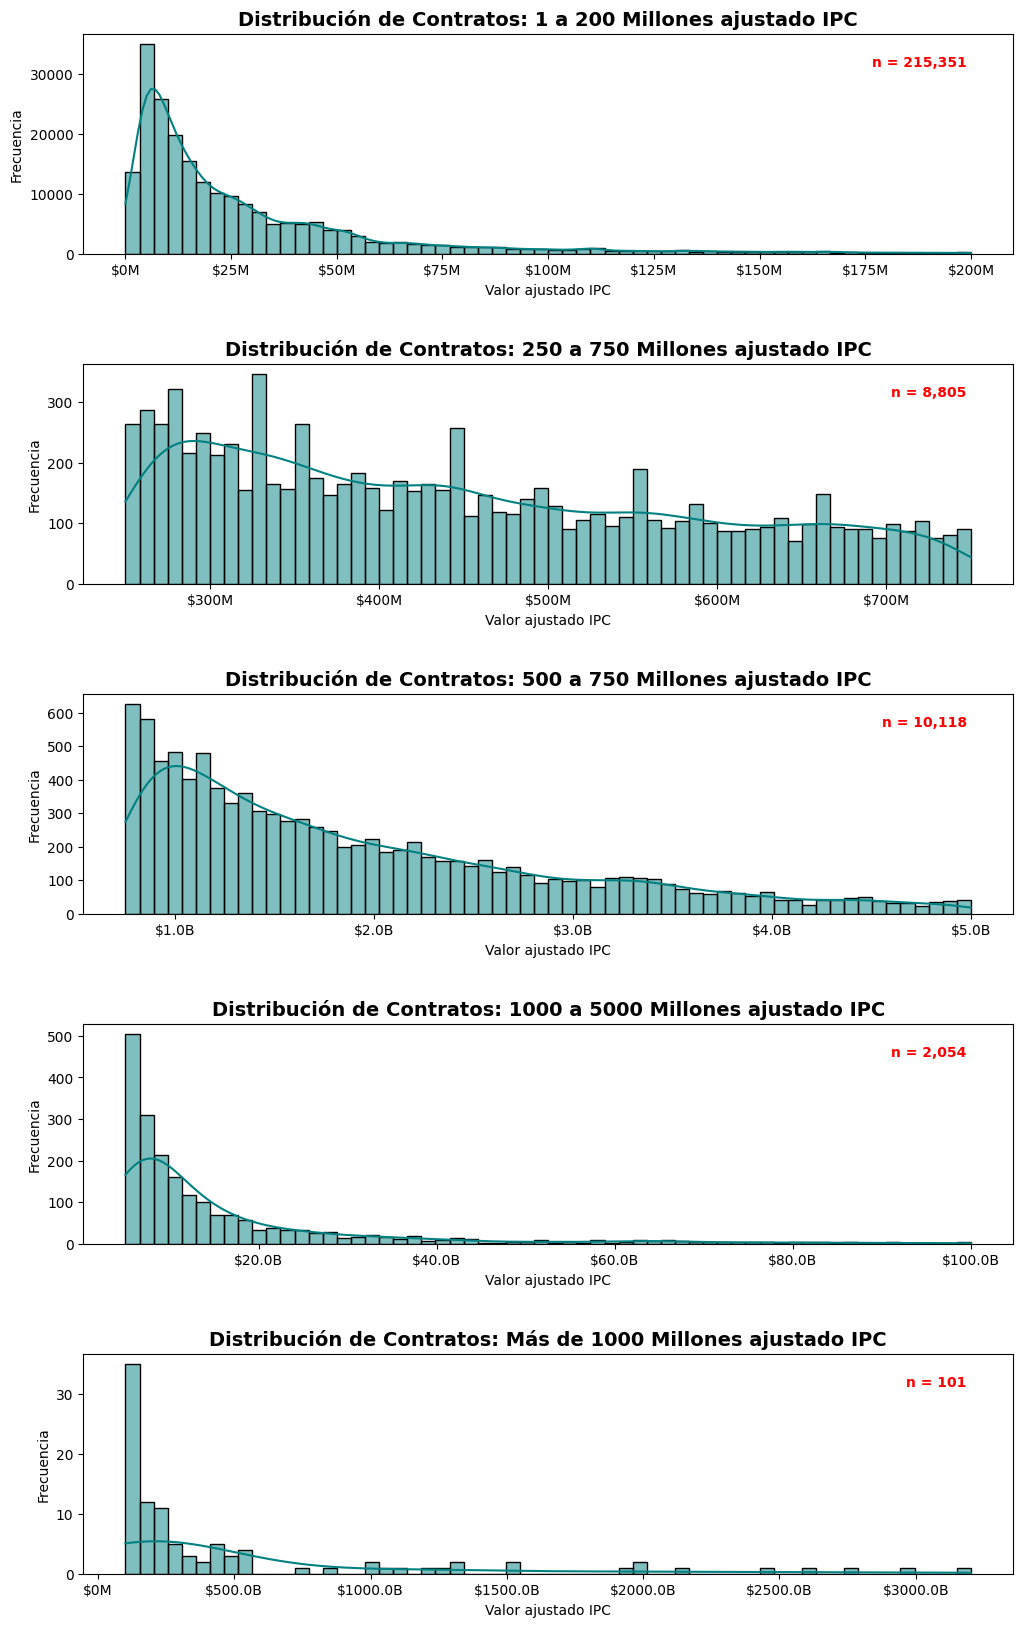

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# 1. Definir los rangos (limite_inferior, limite_superior, titulo)
rangos = [
    (1, 200e6, "1 a 200 Millones ajustado IPC"),
    (250e6, 750e6, "250 a 750 Millones ajustado IPC"),
    (750e6, 5000e6, "500 a 750 Millones ajustado IPC"),
    (5000e6, 100000e6, "1000 a 5000 Millones ajustado IPC"),
    (100000e6, df['valor_contrato'].max(), "Más de 1000 Millones ajustado IPC")
]

# 2. Configurar la figura (5 filas, 1 columna)
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(12, 20))
fig.subplots_adjust(hspace=0.5) # Espacio entre gráficas

# Función para dar formato de Millones/Billones al eje X
def format_money(x, pos):
    if x >= 1e9: return f'${x/1e9:.1f}B'
    return f'${x/1e6:.0f}M'

formatter = FuncFormatter(format_money)

# 3. Iterar y graficar
for i, (bajo, alto, titulo) in enumerate(rangos):
    # Filtrar datos para el rango actual
    data_filtrada = df[(df['valor_ajustado'] >= bajo) & (df['valor_ajustado'] <= alto)]
    
    # Graficar en el subeje correspondiente
    sns.histplot(data_filtrada['valor_ajustado'], bins=60, kde=True, ax=axes[i], color='teal')
    
    # Configurar títulos y etiquetas
    axes[i].set_title(f'Distribución de Contratos: {titulo}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Valor ajustado IPC')
    axes[i].set_ylabel('Frecuencia')
    axes[i].xaxis.set_major_formatter(formatter)
    
    # Añadir un texto con la cantidad de contratos encontrados en ese rango
    axes[i].text(0.95, 0.85, f'n = {len(data_filtrada):,}', 
                 transform=axes[i].transAxes, ha='right', fontweight='bold', color='red')

plt.show()

**Análisis de la distribución de la variable valor_ajustado (valor contrato con IPC)**

*Selección de la distribución para el modelado*

Se opta por trabajar con la primera distribución correspondiente al rango de 1 a 200 millones del valor ajustado del contrato por IPC, debido a las siguientes razones estadísticas y metodológicas:
En primer lugar, esta distribución presenta el mayor tamaño muestral (n ≈ 215,351) en comparación con los demás subconjuntos. Esto garantiza una mayor representatividad estadística, reduciendo la varianza de los estimadores y mejorando la capacidad de generalización del modelo.
En segundo lugar, aunque la variable exhibe una asimetría positiva (cola hacia la derecha), su comportamiento es más continuo y denso en comparación con los rangos superiores, donde se observa una mayor dispersión, presencia de valores extremos y menor densidad de observaciones. Estas características en los rangos altos pueden introducir inestabilidad en el entrenamiento y sesgos en modelos predictivos.
Adicionalmente, la primera distribución refleja de manera más fiel el comportamiento típico del fenómeno estudiado (contratación), evitando que el modelo esté dominado por outliers de alto valor, los cuales, aunque relevantes, son poco frecuentes.

*Transformación propuesta*

Dado que la distribución presenta sesgo positivo, se propone aplicar una transformación logarítmica de y= log(1+x)
Esta transformación se justifica porque:
Reduce la asimetría de la distribución, acercándola a una forma más normal.
Disminuye el impacto de valores extremos.
Mejora el desempeño de modelos que asumen cierta homocedasticidad o relaciones lineales.
Mantiene la interpretabilidad al trabajar con escalas relativas.



Para eliminar ruido solo tomamos lo que este por debajo del percentil 90

In [27]:
limite = df["valor_ajustado"].quantile(0.90)
df_filtrado = df[df["valor_ajustado"] <= limite]

In [28]:
df_filtrado = df_filtrado.drop(columns=['ipc','valor_contrato'])

In [29]:
print(f"numero de filas resultantes {df_filtrado.shape[0]}")

numero de filas resultantes 216817


Limpieza de las filas eliminando tildes, espacios, urls, numeros con la funcion limpieza_total ya creada

In [30]:
from limpieza_texto import limpieza_total

# Definimos las columnas a ignorar
ignore = ['valor_ajustado','anio','duracion_dias','origen','fecha_inicio_ejecucion','fecha_fin_ejecucion','mes']
target_cols = [c for c in df_filtrado.columns if c not in ignore]

# Aplicamos la función 
df_filtrado[target_cols] = df_filtrado[target_cols].map(limpieza_total)


Filas eliminadas en total 

In [31]:
filas_finales=len(df_filtrado)

porcentaje_filas_eliminadas = (filas_iniciales - filas_finales)*100/filas_iniciales

print(f"\n filas finales: {filas_finales}")
print(f"\n filas iniciales dataset: {filas_iniciales}")
print(f"\n porcentaje eliminados: {round(porcentaje_filas_eliminadas,2)} %")


 filas finales: 216817

 filas iniciales dataset: 300000

 porcentaje eliminados: 27.73 %


Tomamos una muestra para el modelo ya que introducri las 216 mil filas tardaria demasiado en modelarse en la cpu

In [32]:
# Tomar una muestra del 30% del dataset
df_sample = df_filtrado.sample(frac=0.3, random_state=42).reset_index(drop=True)
df_sample.shape[0]


65045

In [33]:
df_sample.head() #Dataset para Catboost

,nivel_entidad,nombre_de_la_entidad,departamento_entidad,municipio_entidad,estado_del_proceso,modalidad_de_contratacion,objeto_del_proceso,tipo_de_contrato,origen,duracion_dias,anio,mes,valor_ajustado
0,nacional,instituto geografico agustin codazzi,distrito capital de bogota,no definido,cerrado,contratacion directa,prestacion de servicios profesionales para rea...,prestacion de servicios,SECOPII,333,2019,1,8.390702e+07
1,territorial,empresa social del estado del departamento del...,meta,villavicencio,aprobado,contratacion regimen especial,prestacion de servicios de apoyo a la gestion ...,prestacion de servicios,SECOPII,55,2025,11,5.924133e+06
2,territorial,central administrativa y contable cenac personal,distrito capital de bogota,bogota,terminado,contratacion directa,prestar los servicios profesionales como aseso...,prestacion de servicios,SECOPII,329,2024,1,4.549769e+07
3,territorial,subred integrada de servicios de salud sur occ...,distrito capital de bogota,no definido,modificado,contratacion regimen especial,prestar servicios profesionales a la gestion a...,prestacion de servicios,SECOPII,105,2025,10,1.611169e+07
4,territorial,instituto departamental de cultura del meta,meta,villavicencio,aprobado,contratacion directa,prestacion de servicios artisticos para para g...,prestacion de servicios,SECOPII,45,2025,10,7.213725e+07


In [34]:
# 1. Exportar el DataFrame a CSV para realizar embeddings del modelo lightbm
df_sample.to_csv('data/df_clean_sample.csv', index=False, encoding='utf-8-sig')

print("Archivo exportado correctamente como 'df_clean_sample.csv'")

Archivo exportado correctamente como 'df_clean_sample.csv'


## **MODELO CATBOOST**<br>

**Resumen de la Arquitectura** <br>
Modelo: CatBoost Regressor.
text_features
Procesamiento de Texto: Se utilizan dos modelos un modelo usando Catboost con text_features columna ('objeto del proceso') y 
la duracion en dias como variable numérica, siendo las restantes categoricas y un segundo modelo  usando un mdelo de lenguaje (multilingual-MiniLM-L12-v2) para generar embeddings del objeto_del_proceso, reducidos a 30 componentes principales mediante PCA y entregandolo al modelo Catboost en columnas numericas.

Tratamiento del Target: Aplicación de transformación logarítmica (log1p) sobre el valor del contrato para estabilizar la varianza y normalizar la distribución de precios.

**Métricas de Desempeño** <br>
$R^2$ (Coeficiente de determinación)

MAE (Error Medio Absoluto)

MAPE (Error Porcentual)

RMSE (Raíz del Error Cuadrático Medio) 


## **Ejecutar modelo por CatBoost** <br>

Justificación Técnica: Función de Pérdida y Escalamiento.
Para el entrenamiento de este modelo se ha seleccionado la combinación de Transformación Logarítmica y la función de pérdida RMSE (Root Mean Squared Error) por las siguientes razones:

Estabilización de la Varianza (Heterocedasticidad)
Los datos de contratación pública en el SECOP presentan una alta "asimetría a la derecha": existen muchísimos contratos de montos pequeños y unos pocos contratos de valores extremadamente altos (outliers).

Efecto: Esto evita que los contratos multimillonarios dominen por completo el entrenamiento, permitiendo que el modelo aprenda patrones tanto en contratos pequeños como grandes.

El RMSE eleva el error al cuadrado antes de promediarlo. Esto significa que el modelo recibe un "castigo" mucho más fuerte por errores grandes que por errores pequeños, obligándolo a ser más preciso en sus predicciones más desviadas.

el RMSE es una función suave y derivable, lo que permite que CatBoost encuentre el "mínimo error" de forma más rápida y estable mediante el descenso de gradiente.



In [35]:
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
import numpy as np

# 1. Definimos las listas de columnas por tipo
cat_features = ['nivel_entidad', 'departamento_entidad', 'nombre_de_la_entidad',
                'municipio_entidad', 'estado_del_proceso', 'modalidad_de_contratacion',
                'tipo_de_contrato', 'origen', 'anio', 'mes']

text_features = ['objeto_del_proceso'] # columna de texto
num_features = ['duracion_dias'] # columna numerica

# 2. Crear X e y incluyendo TODAS las columnas
# Seleccionamos la suma de todas las listas de características
X = df_sample[cat_features + text_features + num_features].copy()
y_log = np.log1p(df_sample['valor_ajustado']) 

# 3. Preparar los tipos de datos 
X[cat_features] = X[cat_features].astype(str).fillna('none')
X[text_features] = X[text_features].astype(str).fillna('sin objeto')
X[num_features] = X[num_features].apply(pd.to_numeric, errors='coerce').fillna(0)



In [36]:
# 2. Dividir en entrenamiento y prueba
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

print(f"Entrenamiento: {X_train.shape[0]} filas")
print(f"Prueba: {X_test.shape[0]} filas")

Entrenamiento: 52036 filas
Prueba: 13009 filas


In [37]:
# 3. Crear los "Pools" especificando cuáles son las categóricas
train_pool = Pool(X_train, y_train_log, cat_features=cat_features, text_features=text_features)
test_pool = Pool(X_test, y_test_log, cat_features=cat_features, text_features=text_features)

In [ ]:
# 4. Configurar el regresor incluyendo el procesamiento de texto
model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=8,
    loss_function='RMSE',
    random_seed=42,
    verbose=500,
    early_stopping_rounds=100,
    
    #
)

# 5. Entrenar 
model.fit(train_pool, eval_set=test_pool, plot=True)































































































































MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 1.9053814	test: 1.8903799	best: 1.8903799 (0)	total: 478ms	remaining: 3m 58s
499:	learn: 0.8464966	test: 1.0734679	best: 1.0734015 (498)	total: 3m 12s	remaining: 0us

bestTest = 1.073401524
bestIteration = 498

Shrink model to first 499 iterations.


CatBoostRegressor(depth=8, early_stopping_rounds=100, iterations=500, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=500)

MÉTRICAS EN PESOS
MAE: $10,258,461.87
R2:  0.5014


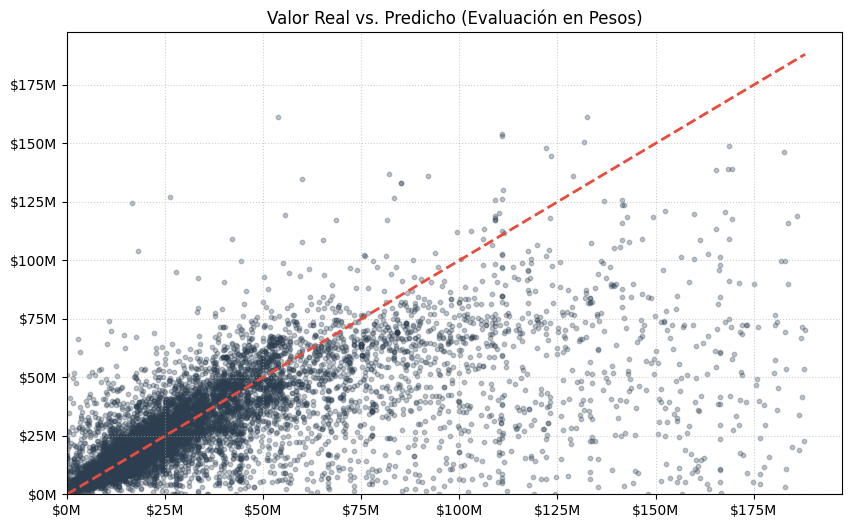

In [39]:
from evaluar_model import evaluar_modelos
# Usamos X_test 
preds_log = model.predict(X_test)

# 7. Llamar a la función de evaluación
# Le pasamos y_test_log (valores reales) y preds_log (lo que el modelo predijo)
evaluar_modelos(y_test_log, preds_log)

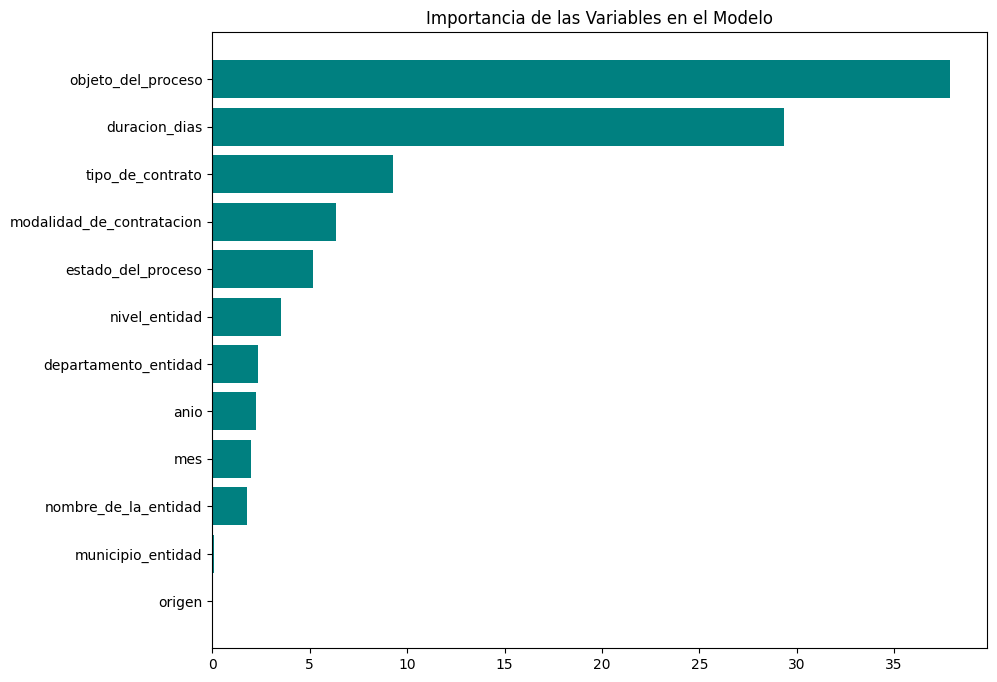

In [40]:
from evaluar_model import graficar_importancia
# Extraemos los nombres de las columnas en el orden exacto
nombres_columnas = X_train.columns.tolist()

# Llamamos a tu función pasando el modelo entrenado y la lista de nombres
graficar_importancia(model, nombres_columnas)

## **Modelo Lightgbm**

llamamos el archivo con embeddings que se genero en collab.

In [41]:

df_embeddings = pd.read_csv('data/df_model_embeddings.csv')

df_embeddings.sample(4)


,nivel_entidad,nombre_de_la_entidad,departamento_entidad,municipio_entidad,estado_del_proceso,modalidad_de_contratacion,tipo_de_contrato,origen,duracion_dias,anio,mes,valor_ajustado,sem_txt_0,sem_txt_1,sem_txt_2,sem_txt_3,sem_txt_4,sem_txt_5,sem_txt_6,sem_txt_7,sem_txt_8,sem_txt_9,sem_txt_10,sem_txt_11,sem_txt_12,sem_txt_13,sem_txt_14,sem_txt_15,sem_txt_16,sem_txt_17,sem_txt_18,sem_txt_19,sem_txt_20,sem_txt_21,sem_txt_22,sem_txt_23,sem_txt_24,sem_txt_25,sem_txt_26,sem_txt_27,sem_txt_28,sem_txt_29
62116,territorial,personeria municipal de sabaneta,antioquia,sabaneta,en ejecucion,contratacion directa,prestacion de servicios,SECOPII,74,2025,10,1.886667e+07,-0.155465,0.501683,0.022686,0.513007,-1.269397,0.011092,-0.174491,-0.146651,0.024322,-0.340720,0.666000,-0.118175,0.396657,0.191367,0.039051,-0.002640,-0.182544,0.516349,0.107327,0.172340,-0.046735,0.086031,-0.161798,0.075892,-0.033704,-0.094054,0.514717,-0.048999,-0.174687,-0.116134
12648,territorial,ese municipal de soacha julio cesar penaloza*,cundinamarca,soacha,aprobado,contratacion regimen especial,decreto de,SECOPII,53,2025,11,5.327059e+06,-0.403520,0.651924,-0.242927,-0.364128,0.258595,0.172323,-0.102006,0.186652,0.328395,0.089458,-0.338638,0.572353,0.156749,-0.497072,-0.249113,0.096161,0.021342,-0.083467,-0.248942,0.141866,0.057258,-0.433283,-0.066268,-0.454016,-0.230781,-0.334694,0.239578,-0.078351,0.004990,0.205148
19246,nacional,fondane direccion territorial centro,distrito capital de bogota,bogota,modificado,contratacion directa,prestacion de servicios,SECOPII,69,2025,9,9.189176e+06,0.378027,-0.339215,-0.166265,-0.833844,0.334467,-0.936849,0.330524,-0.008565,0.523929,0.408250,-0.312335,0.039685,-0.258107,0.459182,-0.077366,-0.332824,-0.053178,0.492491,0.215692,-0.255438,0.302761,-0.079112,0.144352,0.010760,-0.235019,-0.233132,0.017139,-0.173043,-0.028399,0.173866
5203,territorial,indeportes cundinamarca,distrito capital de bogota,no definido,modificado,contratacion directa,prestacion de servicios,SECOPII,254,2025,3,3.699346e+07,0.702181,0.138163,0.325987,1.616283,0.553634,0.159122,-0.907709,-0.008625,0.403932,0.165029,-0.219280,0.086345,-0.308070,-0.249657,-0.320236,0.503845,-0.264311,-0.108018,0.077969,-0.078092,-0.226075,-0.192816,0.028743,0.181043,-0.001189,-0.097158,-0.150656,-0.156114,-0.203441,-0.131436


In [42]:
top = df_embeddings['municipio_entidad'].value_counts().nlargest(50).index

df_embeddings['municipio_entidad'] = df_embeddings['municipio_entidad'].apply(
    lambda x: x if x in top else 'OTROS'
)

In [43]:
import numpy as np
from sklearn.model_selection import train_test_split
from lightgbm import LGBMRegressor

# 1. Target (log)
y = np.log1p(df_embeddings['valor_ajustado'])

X = df_embeddings.drop(columns=[
    'valor_ajustado',
    'nombre_de_la_entidad',
      ])



# 3. Columnas categóricas
cat_features = [
    'nivel_entidad', 'departamento_entidad', 'municipio_entidad'
    'estado_del_proceso', 'modalidad_de_contratacion', 
    'tipo_de_contrato', 'origen', 'anio', 'mes'
]

# 4. Convertir a categoría
for col in cat_features:
    if col in X.columns:
        X[col] = X[col].astype('category')

# 5. Train / Test split
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

for col in cat_features:
    if col in X_train.columns:
        X_train[col] = X_train[col].astype('category')
        X_test[col] = X_test[col].astype('category')

# 6. Modelo
lgbm_model = LGBMRegressor(
    objective='regression',
    n_estimators=2000,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)

# 7. Entrenamiento
print("Entrenando LightGBM con Embeddings...")
lgbm_model.fit(
    X_train, y_train_log,
    eval_set=[(X_test, y_test_log)],
    categorical_feature=cat_features
)

# 8. Predicciones
preds_lgbm = lgbm_model.predict(X_test)


Entrenando LightGBM con Embeddings...


ValueError: pandas dtypes must be int, float or bool.
Fields with bad pandas dtypes: municipio_entidad: object, estado_del_proceso: object

In [ ]:
import numpy as np

preds_real = np.expm1(preds_lgbm)
y_test_real = np.expm1(y_test_log)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

rmse = np.sqrt(mean_squared_error(y_test_real, preds_real))
r2 = r2_score(y_test_real, preds_real)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 19661177.556433666
R2: 0.6191009678409081
